In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
df = pd.read_csv('dbl_south_region_boys_games.csv')

In [3]:
df.info

<bound method DataFrame.info of      game_id        date  season_year            series        region  \
0        807  2019-08-31         2019  East Java Series  South Region   
1        808  2019-08-31         2019  East Java Series  South Region   
2        809  2019-08-31         2019  East Java Series  South Region   
3        810  2019-08-31         2019  East Java Series  South Region   
4        821  2019-09-01         2019  East Java Series  South Region   
..       ...         ...          ...               ...           ...   
518    12319  2026-09-02         2026  East Java Series  South Region   
519    12401  2026-09-04         2026  East Java Series  South Region   
520    12402  2026-09-04         2026  East Java Series  South Region   
521    12399  2026-09-04         2026  East Java Series  South Region   
522    12400  2026-09-04         2026  East Java Series  South Region   

    category                     round                 venue time_wib  \
0       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:30   
1       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:30   
2       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:30   
3       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:30   
4       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:10   
..       ...                       ...                   ...      ...   
518     Boys               Fantastic 4   GOR Ken Arok Malang    18:45   
519     Boys                     Final   GOR Ken Arok Malang    17:30   
520     Boys                     Final   GOR Ken Arok Malang    17:30   
521     Boys                     Final   GOR Ken Arok Malang    17:30   
522     Boys                     Final   GOR Ken Arok Malang    17:30   

                             home_team      away_team  home_score  away_score  \
0                    MAN 2 KOTA MALANG  SMAN 4 MALANG          24          15   
1                    MAN 2 KOTA MALANG  SMAN 4 MALANG          24          15   
2                    MAN 2 KOTA MALANG  SMAN 4 MALANG          24          15   
3                    MAN 2 KOTA MALANG  SMAN 4 MALANG          24          15   
4    SMA BRAWIJAYA SMART SCHOOL MALANG  SMAN 3 BLITAR          32          37   
..                                 ...            ...         ...         ...   
518                  MAN 2 KOTA MALANG  SMAN 3 MALANG           4           2   
519                  MAN 2 KOTA MALANG    SMAN 1 BATU           8           5   
520                  MAN 2 KOTA MALANG    SMAN 1 BATU           8           5   
521                  MAN 2 KOTA MALANG    SMAN 1 BATU           8           5   
522                  MAN 2 KOTA MALANG    SMAN 1 BATU           8           5   

                winner  margin                             source_url  
0    MAN 2 KOTA MALANG       9    https://www.dbl.id/match/detail/807  
1    MAN 2 KOTA MALANG       9    https://www.dbl.id/match/detail/808  
2    MAN 2 KOTA MALANG       9    https://www.dbl.id/match/detail/809  
3    MAN 2 KOTA MALANG       9    https://www.dbl.id/match/detail/810  
4        SMAN 3 BLITAR       5    https://www.dbl.id/match/detail/821  
..                 ...     ...                                    ...  
518  MAN 2 KOTA MALANG       2  https://www.dbl.id/match/detail/12319  
519  MAN 2 KOTA MALANG       3  https://www.dbl.id/match/detail/12401  
520  MAN 2 KOTA MALANG       3  https://www.dbl.id/match/detail/12402  
521  MAN 2 KOTA MALANG       3  https://www.dbl.id/match/detail/12399  
522  MAN 2 KOTA MALANG       3  https://www.dbl.id/match/detail/12400  

[523 rows x 16 columns]>

In [4]:
df.shape

(523, 16)

In [5]:
df.head()
df.tail()

,game_id,date,season_year,series,region,category,round,venue,time_wib,home_team,away_team,home_score,away_score,winner,margin,source_url
518,12319,2026-09-02,2026,East Java Series,South Region,Boys,Fantastic 4,GOR Ken Arok Malang,18:45,MAN 2 KOTA MALANG,SMAN 3 MALANG,4,2,MAN 2 KOTA MALANG,2,https://www.dbl.id/match/detail/12319
519,12401,2026-09-04,2026,East Java Series,South Region,Boys,Final,GOR Ken Arok Malang,17:30,MAN 2 KOTA MALANG,SMAN 1 BATU,8,5,MAN 2 KOTA MALANG,3,https://www.dbl.id/match/detail/12401
520,12402,2026-09-04,2026,East Java Series,South Region,Boys,Final,GOR Ken Arok Malang,17:30,MAN 2 KOTA MALANG,SMAN 1 BATU,8,5,MAN 2 KOTA MALANG,3,https://www.dbl.id/match/detail/12402
521,12399,2026-09-04,2026,East Java Series,South Region,Boys,Final,GOR Ken Arok Malang,17:30,MAN 2 KOTA MALANG,SMAN 1 BATU,8,5,MAN 2 KOTA MALANG,3,https://www.dbl.id/match/detail/12399
522,12400,2026-09-04,2026,East Java Series,South Region,Boys,Final,GOR Ken Arok Malang,17:30,MAN 2 KOTA MALANG,SMAN 1 BATU,8,5,MAN 2 KOTA MALANG,3,https://www.dbl.id/match/detail/12400


In [6]:
df.describe()

,game_id,season_year,home_score,away_score,margin
count,523.000000,523.000000,523.000000,523.000000,523.000000
mean,6548.460803,2023.497132,19.881453,18.697897,13.214149
std,3788.067182,2.288044,18.181432,18.025008,14.539945
min,807.000000,2019.000000,0.000000,0.000000,1.000000
25%,3131.500000,2022.000000,4.000000,5.000000,2.000000
50%,6398.000000,2024.000000,11.000000,12.000000,7.000000
75%,8956.500000,2025.000000,32.000000,29.000000,17.000000
max,12402.000000,2026.000000,84.000000,71.000000,69.000000


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2) #pct = percentage
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).head(10)

,missing_count,missing_pct
game_id,0,0.0
date,0,0.0
season_year,0,0.0
series,0,0.0
region,0,0.0
category,0,0.0
round,0,0.0
venue,0,0.0
time_wib,0,0.0
home_team,0,0.0


In [13]:
#handle missing value numerikal
df_cpy_num1 = df.copy()
home_score_by_away_score = df_cpy_num1.groupby('away_score')['home_score'].transform('median')
df_cpy_num1['home_score'] = df_cpy_num1['home_score'].fillna(home_score_by_away_score)

df_cpy_num1[['home_score']].isna().sum()

,0
home_score,0


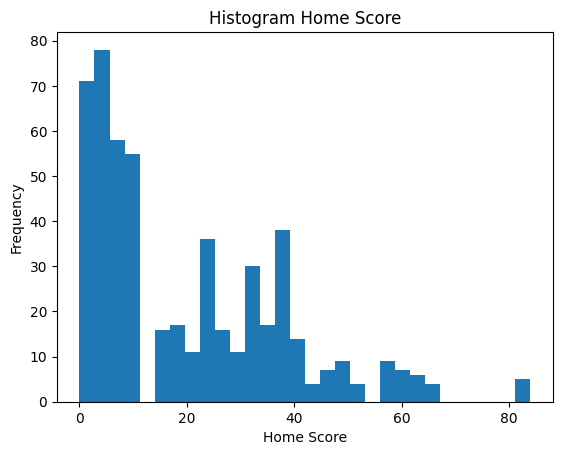

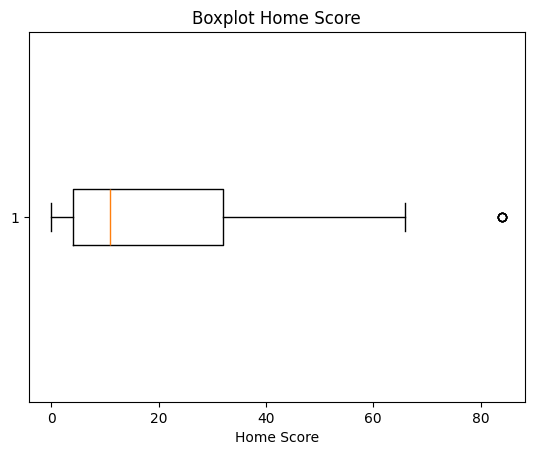

In [11]:
#boxplot dan histogram
num_cols = ['home_score','away_Score']

plt.figure
plt.hist(df['home_score'].dropna(),bins=30)
plt.title('Histogram Home Score')
plt.xlabel('Home Score')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.boxplot(df['home_score'].dropna(),vert=False)
plt.title('Boxplot Home Score')
plt.xlabel('Home Score')
plt.show()